# Time Series Analysis Project

## Import Libraries

In [36]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose

## Import Data

In [37]:
delhi_climate_df = pd.read_csv("dataset/DailyDelhiClimate.csv")

## Data Inspection 

In [110]:
# Top 5 rows of the  data
delhi_climate_df.head()

,date,mean_temp,humidity,wind_speed,mean_pressure
0,01/01/2013,10.000000,84.500000,0.000000,1015.666667
1,02/01/2013,7.400000,92.000000,2.980000,1017.800000
2,03/01/2013,7.166667,87.000000,4.633333,1018.666667
3,04/01/2013,8.666667,71.333333,1.233333,1017.166667
4,05/01/2013,6.000000,86.833333,3.700000,1016.500000


In [11]:
# Basic information
delhi_climate_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1462 entries, 0 to 1461
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           1462 non-null   object 
 1   mean_temp      1462 non-null   float64
 2   humidity       1462 non-null   float64
 3   wind_speed     1462 non-null   float64
 4   mean_pressure  1462 non-null   float64
dtypes: float64(4), object(1)
memory usage: 57.2+ KB


In [17]:
# Summary Statistics
delhi_climate_df.describe().T

,count,mean,std,min,25%,50%,75%,max
mean_temp,1462.0,25.495521,7.348103,6.000000,18.857143,27.714286,31.305804,38.714286
humidity,1462.0,60.771702,16.769652,13.428571,50.375000,62.625000,72.218750,100.000000
wind_speed,1462.0,6.802209,4.561602,0.000000,3.475000,6.221667,9.238235,42.220000
mean_pressure,1462.0,1011.104548,180.231668,-3.041667,1001.580357,1008.563492,1014.944901,7679.333333


## Data Cleaning and Preparation

In [20]:
# Check for missing values
delhi_climate_df.isnull().sum()

date             0
mean_temp        0
humidity         0
wind_speed       0
mean_pressure    0
dtype: int64

In [22]:
# check duplicates rows
delhi_climate_df.duplicated().sum()

0

In [38]:
# Fix datetime format
delhi_climate_df["date"] = pd.to_datetime(delhi_climate_df['date'], dayfirst= True)

In [39]:
# Sort the date values
delhi_climate_df = delhi_climate_df.sort_values("date")

In [40]:
delhi_climate_df["date"]

0      2013-01-01
1      2013-01-02
2      2013-01-03
3      2013-01-04
4      2013-01-05
          ...    
1457   2016-12-28
1458   2016-12-29
1459   2016-12-30
1460   2016-12-31
1461   2017-01-01
Name: date, Length: 1462, dtype: datetime64[ns]

In [41]:
# Set date as index
delhi_climate_df = delhi_climate_df.set_index("date")

## Data Visualization

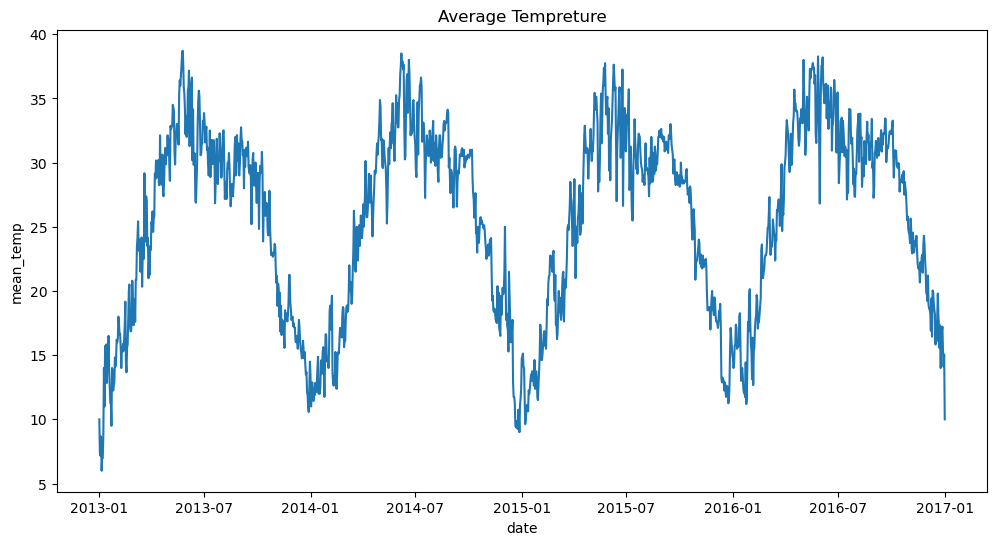

In [16]:
plt.figure(figsize = (12,6))
sns.lineplot(delhi_climate_df["mean_temp"])
plt.title("Average Tempreture")
plt.show()

## Decomposition of Time Series

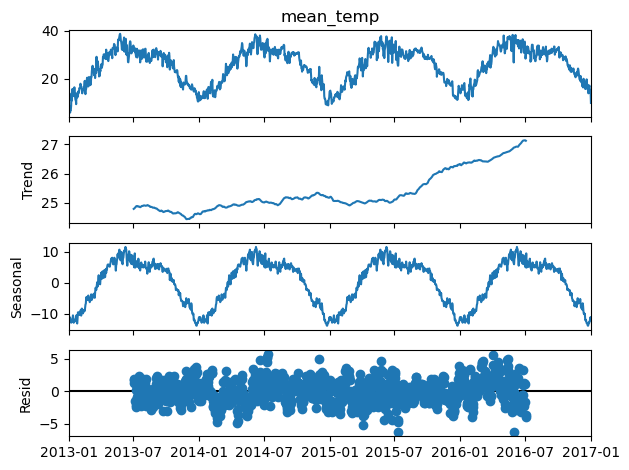

In [24]:
decomposition = seasonal_decompose(
    delhi_climate_df["mean_temp"],
    model = "additive",
    period = 365
)
decomposition.plot()
plt.show()

## Moving Average

In [42]:
delhi_climate_df["moving_average"] = delhi_climate_df["mean_temp"].rolling(window = 7).mean()

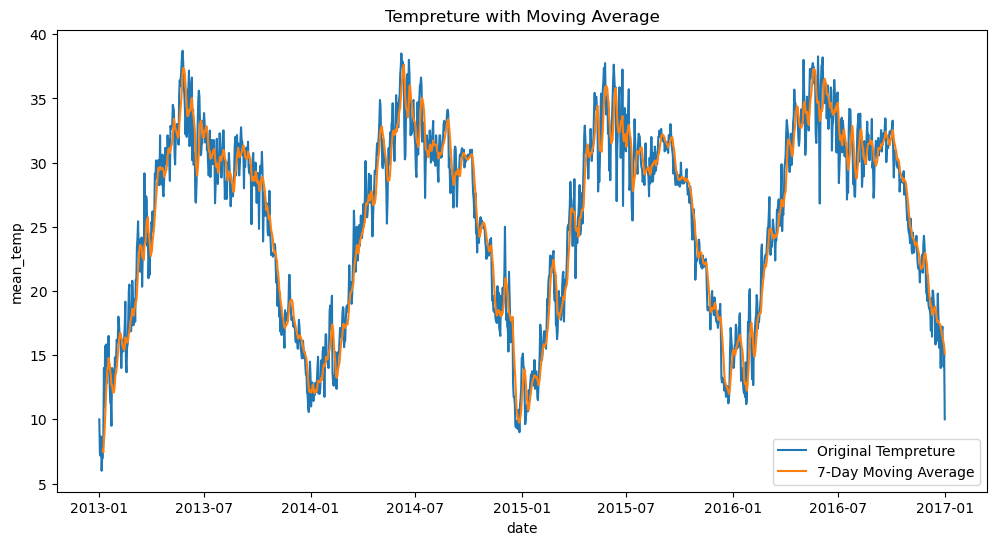

In [43]:
plt.figure(figsize = (12,6))
sns.lineplot(delhi_climate_df["mean_temp"], label = "Original Tempreture")
sns.lineplot(delhi_climate_df["moving_average"], label = "7-Day Moving Average")
plt.title("Tempreture with Moving Average")
plt.show()